# I. Introduction

Final Project

- Batch : HCK-037

Notebook ini dibuat untuk ...

# II. Project Libraries

In [2]:
import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve, cross_validate

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from feature_engine.outliers import Winsorizer

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Python statistics
from scipy import stats
from scipy.stats import kendalltau, pearsonr, spearmanr

# III. Data Loading

## 3.1. Loading Dataset from CSV

In [22]:
# Melakukan loading dataset dari file CSV
df = pd.read_csv("cs-training.csv")
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [23]:
# Option B: Modifying in place
df.drop('Unnamed: 0', axis=1, inplace=True)
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [24]:
# Display jumlah data dan tipe data dari setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

## 3.2. Handling Duplicated Data

### 3.2.1. Checking Duplicated Data Amount

In [25]:
# Jumlah data yang merupakan duplikasi dari data lain
df.duplicated().sum()

609

## 3.3. Backing Up Dataframe

In [26]:
# Melakukan backup terhadap dataframe
df_backup = df.copy()

Backup dilakukan supaya kita dapat tetap mengakses dataframe original sebelum dilakukan cleaning.

## 3.4. Analyzing Dataset

In [27]:
# Numerical statistical summary
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [28]:
df.loc[df["age"] <= 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [29]:
df["LogIncome"] = np.log1p(df["MonthlyIncome"])

df["MonthlyDebt"] = np.log1p(df["MonthlyIncome"] * df["DebtRatio"])

df["WeightedLateScore"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] * 1 +
    df["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
    df["NumberOfTimes90DaysLate"]   * 4
)

df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,LogIncome,MonthlyDebt,WeightedLateScore
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,9.118335,8.898939,2
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,7.863651,5.761668,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,8.020599,5.560354,5
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,8.101981,4.787191,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,11.060196,7.368955,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0,7.650169,6.160732,0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0,8.627840,8.294620,0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0,NaN,NaN,0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0,8.651199,0.000000,0


In [30]:
print(df["NumberOfTime30-59DaysPastDueNotWorse"].unique())
print(df["NumberOfTime60-89DaysPastDueNotWorse"].unique())
print(df["NumberOfTimes90DaysLate"].unique())
print(df["WeightedLateScore"].unique())

[ 2  0  1  3  4  5  7 10  6 98 12  8  9 96 13 11]
[ 0  1  2  5  3 98  4  6  7  8 96 11  9]
[ 0  1  3  2  5  4 98 10  9  6  7  8 15 96 11 13 14 17 12]
[  2   0   5   1  17   3   4   6  12  13   7  10   8  14  15  28   9  20
  18  24  16  19 686  11  22  21  41  45  26  31  30  35  25  32  27  23
  29  42  39  53  33  61  36  40  48 672  37  38  34  44  52  59  68  47
  58  54  51  57]


In [31]:
# Drop duplicated data
df.drop_duplicates(inplace=True)
print(f"Shape setelah drop duplicates: {df.shape}")

# Drop baris dengan age <= 0 (data error)
df = df[df['age'] > 0]
print(f"Shape setelah drop age <= 0: {df.shape}")

Shape setelah drop duplicates: (149391, 14)
Shape setelah drop age <= 0: (149390, 14)


# IV. Exploratory Data Analysis

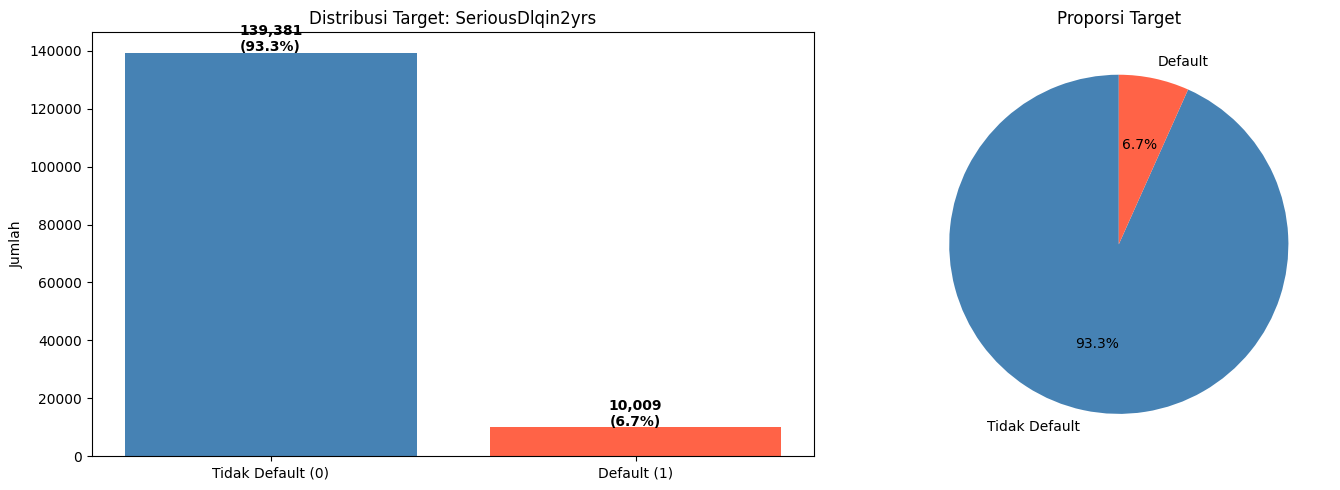

Ratio imbalance: 13.9 : 1


In [32]:
# Distribusi target variable
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

target_counts = df['SeriousDlqin2yrs'].value_counts()

# Bar chart
axes[0].bar(['Tidak Default (0)', 'Default (1)'], target_counts.values, 
            color=['steelblue', 'tomato'])
axes[0].set_title('Distribusi Target: SeriousDlqin2yrs')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Tidak Default', 'Default'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporsi Target')

plt.tight_layout()
plt.show()

print(f"Ratio imbalance: {round(target_counts[0]/target_counts[1], 1)} : 1")

Implikasi ke metrik evaluasi:

- Jangan pakai Accuracy sebagai metrik utama — model yang selalu prediksi "tidak default" pun bisa dapat accuracy 93%, tapi tidak berguna sama sekali
- Metrik yang lebih relevan: Recall untuk kelas Default (kita tidak mau miss orang yang sebenarnya akan default), AUC-ROC, dan F1-score

Implikasi ke model:

- Nanti perlu handling imbalance, salah satu caranya dengan parameter scale_pos_weight di XGBoost (kita set ke ~13.9) agar model tidak bias ke kelas mayoritas

Dari sisi bisnis:

- Lembaga pemberi kredit lebih takut False Negative (prediksi tidak default, padahal default) daripada False Positive (prediksi default, padahal tidak) — karena kerugian finansialnya lebih besar
Jadi Recall kelas Default harus setinggi mungkin

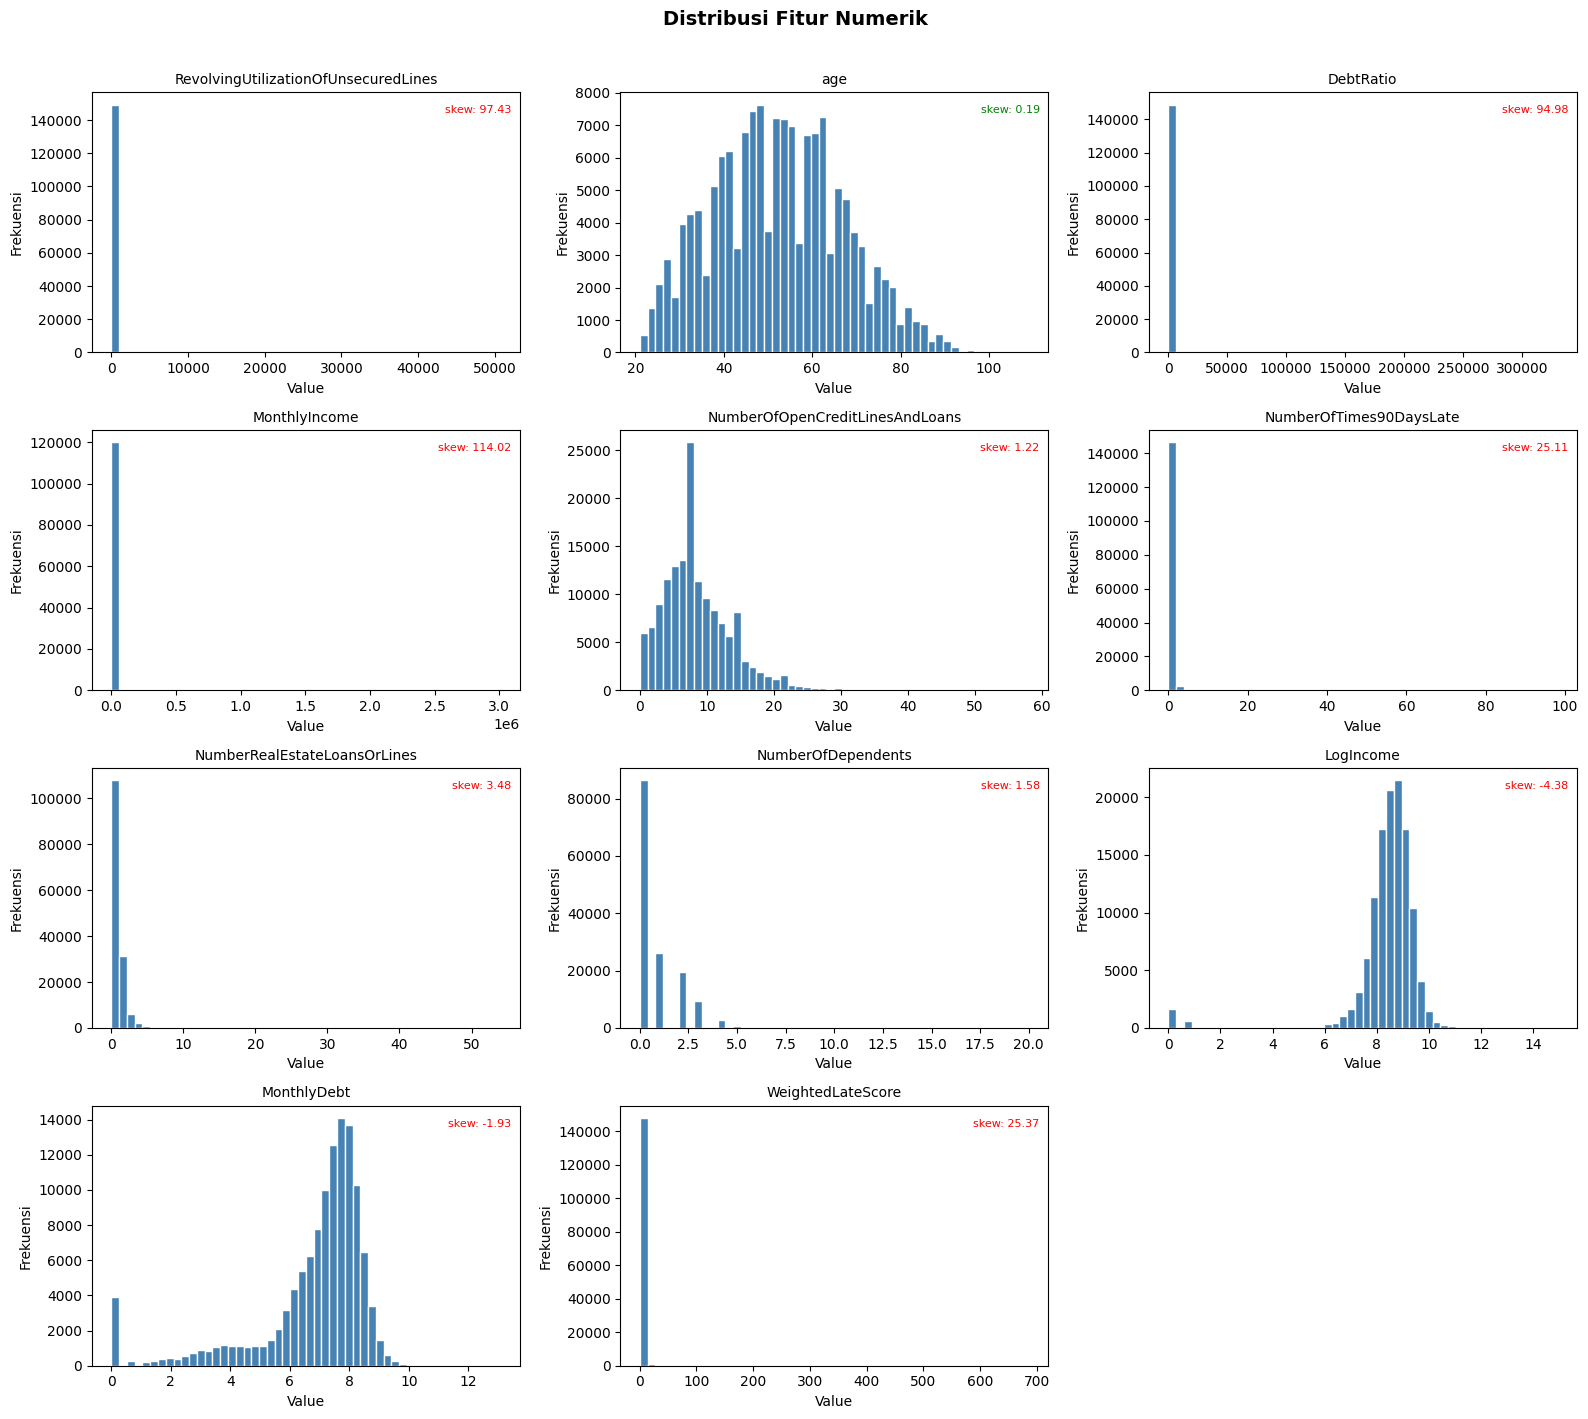

In [33]:
# Distribusi fitur numerik
num_features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines', 'NumberOfDependents',
    'LogIncome', 'MonthlyDebt', 'WeightedLateScore'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frekuensi')
    
    # Tambahkan info skewness
    skew = df[col].skew()
    axes[i].text(0.98, 0.95, f'skew: {skew:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8,
                 color='red' if abs(skew) > 1 else 'green')

# Sembunyikan subplot kosong
axes[-1].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Distribusi Normal (aman):

- age — skew 0.19, distribusi paling normal di antara semua fitur, tidak perlu treatment khusus
- MonthlyDebt — skew -1.93, agak left-skewed tapi masih jauh lebih baik dari yang lain
- LogIncome — skew -4.38, left-skewed tapi ini memang sudah hasil transformasi log dari MonthlyIncome

Skewness Ekstrem (perlu handling serius):

- RevolvingUtilizationOfUnsecuredLines — skew 97.43, ini tidak wajar, hampir pasti ada outlier ekstrem
- DebtRatio — skew 94.98, sama, nilai max 300.000+ jelas tidak masuk akal untuk debt ratio
- MonthlyIncome — skew 114.02, ada nilai yang sangat ekstrem di kanan
- NumberOfTimes90DaysLate dan WeightedLateScore — skew 25+, ini yang kemungkinan besar mengandung sentinel values 96/98 yang tadi kita curigai

Kesimpulan yang bisa diambil:

- Fitur dengan skew ekstrem perlu outlier handling sebelum modeling
- WeightedLateScore max sampai 700 itu mencurigakan — ini langsung mengarah ke pengecekan sentinel value di nomor 4

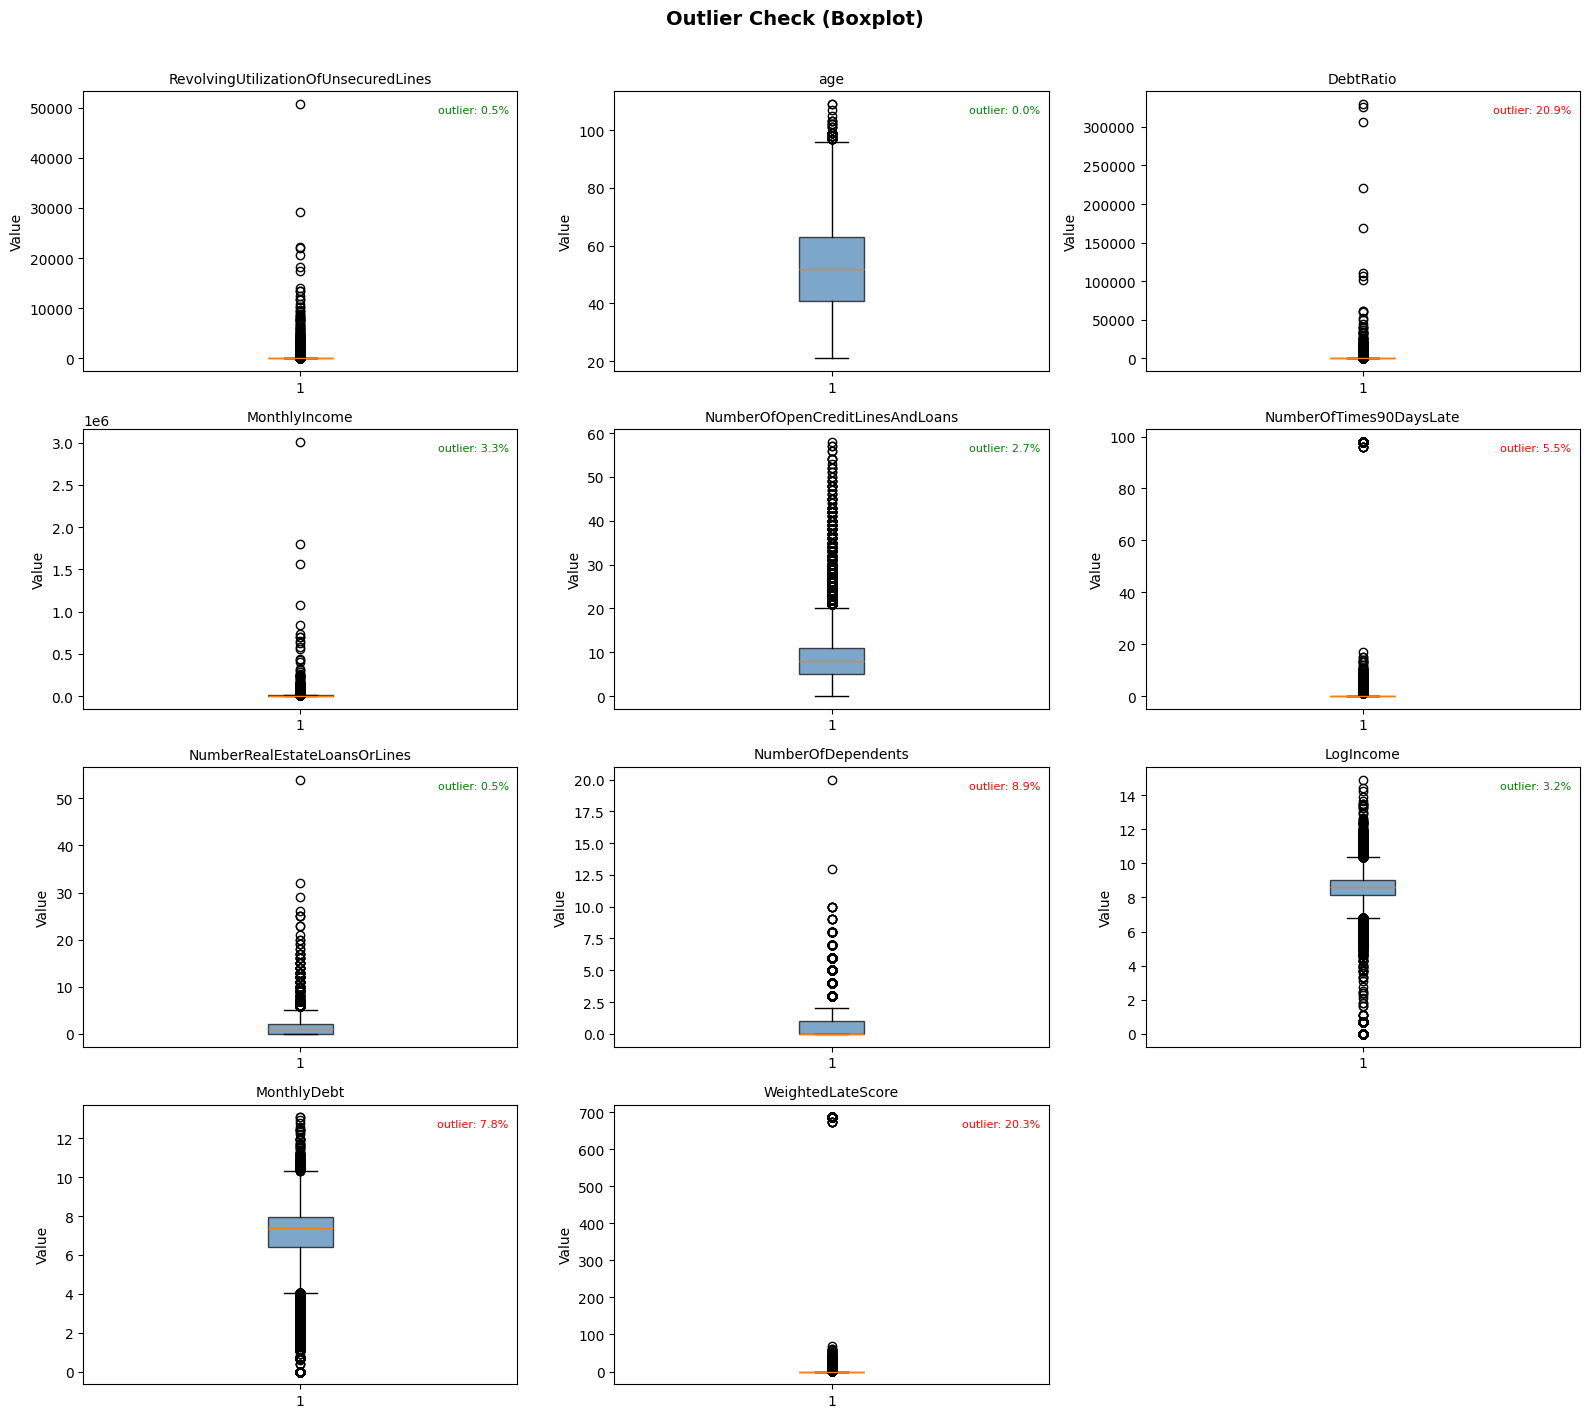

In [34]:
# Outlier check dengan boxplot
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')
    
    # Hitung % outlier berdasarkan IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    pct = outlier_mask.sum() / len(df) * 100
    axes[i].text(0.98, 0.95, f'outlier: {pct:.1f}%', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8,
                 color='red' if pct > 5 else 'green')

axes[-1].set_visible(False)

plt.suptitle('Outlier Check (Boxplot)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [35]:
# Statistik outlier per kolom
print(f"{'Kolom':<45} {'% Outlier':>10} {'Min':>12} {'Max':>15}")
print("-" * 85)

for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    pct = outlier_mask.sum() / len(df) * 100
    print(f"{col:<45} {pct:>9.1f}% {df[col].min():>12.2f} {df[col].max():>15.2f}")

Kolom                                          % Outlier          Min             Max
-------------------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines                0.5%         0.00        50708.00
age                                                 0.0%        21.00          109.00
DebtRatio                                          20.9%         0.00       329664.00
MonthlyIncome                                       3.3%         0.00      3008750.00
NumberOfOpenCreditLinesAndLoans                     2.7%         0.00           58.00
NumberOfTimes90DaysLate                             5.5%         0.00           98.00
NumberRealEstateLoansOrLines                        0.5%         0.00           54.00
NumberOfDependents                                  8.9%         0.00           20.00
LogIncome                                           3.2%         0.00           14.92
MonthlyDebt                                         7.

Outlier Wajar (tidak perlu khawatir):

- age — 0.0% outlier, min 21 max 109, masuk akal
- RevolvingUtilizationOfUnsecuredLines — 0.5% outlier, tapi max 50708 sangat tidak wajar (harusnya 0-1), ini jelas data error
- NumberRealEstateLoansOrLines — 0.5%, masih wajar

Outlier Bermasalah:

- DebtRatio — 20.9% outlier, max 329664! Debt ratio harusnya rasio, tidak mungkin sebesar itu
- WeightedLateScore — 20.3% outlier, max 686 — ini langsung berkaitan dengan sentinel values 96/98 yang belum kita handle
- NumberOfDependents — 8.9%, max 20 tanggungan, sangat tidak wajar
- MonthlyDebt — 7.8%
- NumberOfTimes90DaysLate — 5.5%, max 98 — ini pasti sentinel value

Kesimpulan penting:
- WeightedLateScore outlier 20.3% dan NumberOfTimes90DaysLate max 98 ini saling berkaitan — sentinel values 96/98 di kolom late payment yang "meracuni" WeightedLateScore juga.

In [36]:
# Sentinel value check pada kolom late payment
cols_late = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

print("=== Distribusi nilai unik kolom late payment ===\n")
for col in cols_late:
    print(f"{col}:")
    print(df[col].value_counts().sort_index().to_string())
    print(f"Jumlah baris dengan nilai >= 90: {(df[col] >= 90).sum()}")
    print()

=== Distribusi nilai unik kolom late payment ===

NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
0     125453
1      16032
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       220
Jumlah baris dengan nilai >= 90: 225

NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
0     141830
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       220
Jumlah baris dengan nilai >= 90: 225

NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
0     141107
1       5232
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       220
Jumlah baris dengan nilai >= 90: 225



- Sentinel value adalah nilai khusus yang digunakan untuk merepresentasikan sesuatu yang "tidak normal" atau "tidak diketahui" — bukan nilai data yang sebenarnya. Jadi bukan outlier murni, tapi kode yang disalahgunakan sebagai angka.

- Contoh di dataset kita: nilai 96 dan 98 di kolom late payment. Secara logika bisnis, tidak mungkin seseorang terlambat bayar 96 atau 98 kali — itu pasti kode yang dipakai untuk merepresentasikan sesuatu seperti "data tidak tersedia" atau "error input".
Kalau tidak dihandle, nilai ini akan dianggap model sebagai orang yang sangat sering terlambat bayar — padahal artinya berbeda. Inilah yang membuat WeightedLateScore bisa mencapai 686.

Hasil :

- Ketiga kolom late payment semuanya punya nilai 96 dan 98
Jumlah baris terdampak 225 baris di setiap kolom — dan angkanya sama persis, artinya baris yang sama yang punya nilai 96/98 di ketiga kolom sekaligus
Nilai 96/98 ini lompat jauh dari nilai normal yang max-nya hanya 13-17 — jelas bukan nilai nyata

- Kenapa 96 dan 98 khususnya?
Ini kemungkinan besar kode legacy dari sistem input data — 96 biasanya berarti "not applicable" dan 98 berarti "unknown/missing". Jadi sebenarnya ini adalah missing value yang disamarkan sebagai angka.
Sekarang kita punya dua pilihan handling:

- Drop baris yang mengandung nilai 96/98 — simple, tapi kehilangan 225 baris
- Imputasi dengan median kolom tersebut (exclude nilai 96/98) — lebih konservatif, tidak kehilangan data


IMPUTASI MEDIAN 

In [ ]:
# Reset copy status dataframe
# df = df.copy()
# Untuk hilangkan warning
# Imputasi sentinel values 96/98 dengan median (exclude sentinel values itu sendiri)
cols_late = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in cols_late:
    median_val = df[df[col] < 90][col].median()
    print(f"{col} — median (exclude sentinel): {median_val}")
    df.loc[df[col] >= 90, col] = median_val

# Hitung ulang WeightedLateScore setelah sentinel values dikoreksi
df['WeightedLateScore'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df['NumberOfTimes90DaysLate'] * 4
)

print(f"\nWeightedLateScore setelah koreksi:")
print(df['WeightedLateScore'].describe())

NumberOfTime30-59DaysPastDueNotWorse — median (exclude sentinel): 0.0
NumberOfTime60-89DaysPastDueNotWorse — median (exclude sentinel): 0.0
NumberOfTimes90DaysLate — median (exclude sentinel): 0.0

WeightedLateScore setelah koreksi:
count    149390.000000
mean          0.738644
std           2.517036
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          68.000000
Name: WeightedLateScore, dtype: float64


C:\Users\rezha\AppData\Local\Temp\ipykernel_19724\2475510382.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WeightedLateScore'] = (


 - median ketiga kolom late payment adalah 0.0, artinya mayoritas orang di dataset ini tidak pernah terlambat bayar sama sekali. Ini konsisten dengan temuan class imbalance tadi (93.3% tidak default).

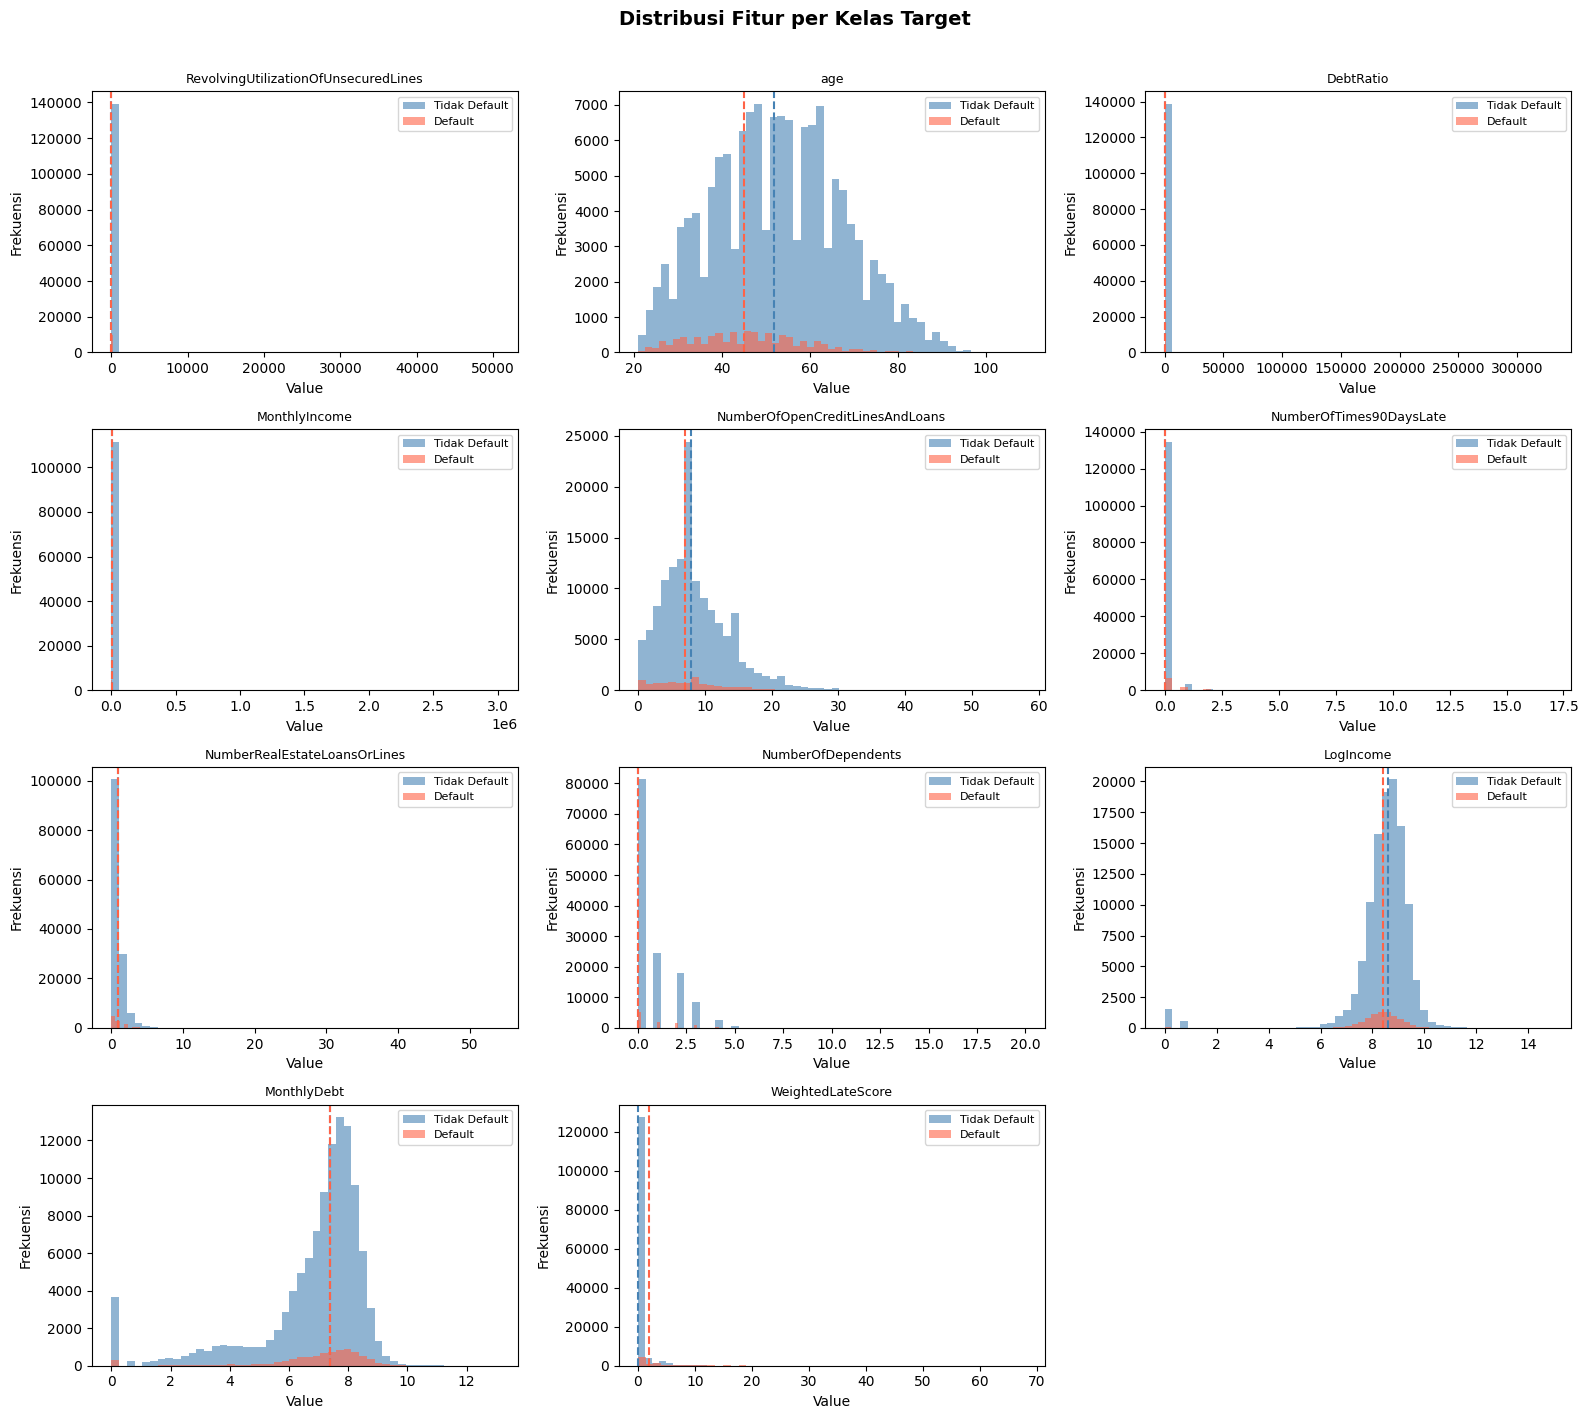


Kolom                                          Median No Default  Median Default    Beda?
------------------------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines                       0.133           0.838        ✓
age                                                       52.000          45.000        ✓
DebtRatio                                                  0.364           0.429        ✓
MonthlyIncome                                           5475.000        4500.000        ✓
NumberOfOpenCreditLinesAndLoans                            8.000           7.000        ✓
NumberOfTimes90DaysLate                                    0.000           0.000        ✗
NumberRealEstateLoansOrLines                               1.000           1.000        ✗
NumberOfDependents                                         0.000           0.000        ✗
LogIncome                                                  8.608           8.412        ✓
MonthlyD

In [40]:
# Distribusi fitur per kelas target
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    default = df[df['SeriousDlqin2yrs'] == 1][col].dropna()
    no_default = df[df['SeriousDlqin2yrs'] == 0][col].dropna()
    
    axes[i].hist(no_default, bins=50, alpha=0.6, color='steelblue', label='Tidak Default')
    axes[i].hist(default, bins=50, alpha=0.6, color='tomato', label='Default')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)
    
    # Tambahkan median masing-masing kelas
    axes[i].axvline(no_default.median(), color='steelblue', linestyle='--', linewidth=1.5)
    axes[i].axvline(default.median(), color='tomato', linestyle='--', linewidth=1.5)

axes[-1].set_visible(False)

plt.suptitle('Distribusi Fitur per Kelas Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Tampilkan median per kelas dalam tabel
print(f"\n{'Kolom':<45} {'Median No Default':>18} {'Median Default':>15} {'Beda?':>8}")
print("-" * 90)
for col in num_features:
    med_no = df[df['SeriousDlqin2yrs'] == 0][col].median()
    med_yes = df[df['SeriousDlqin2yrs'] == 1][col].median()
    beda = "✓" if abs(med_no - med_yes) > 0 else "✗"
    print(f"{col:<45} {med_no:>18.3f} {med_yes:>15.3f} {beda:>8}")

Fitur yang Membedakan Default vs Tidak Default dengan Jelas:

- RevolvingUtilizationOfUnsecuredLines — median default 0.838 vs 0.133, perbedaan sangat besar! Ini kemungkinan fitur terpenting
- age — default rata-rata lebih muda (45) vs tidak default (52), masuk akal secara bisnis
- WeightedLateScore — median default 2.0 vs 0.0, konsisten dengan logika — orang yang default memang punya riwayat telat bayar lebih banyak
- MonthlyIncome — default punya income lebih rendah (4500 vs 5475)

Fitur yang Tidak Membedakan (Median Sama):

- NumberOfTimes90DaysLate — keduanya median 0.0
- NumberRealEstateLoansOrLines — keduanya 1.0
- NumberOfDependents — keduanya 0.0

Insight penting:
- NumberOfTimes90DaysLate, NumberRealEstateLoansOrLines, dan NumberOfDependents mediannya sama persis — ini kandidat untuk di-drop di feature selection nanti. Tapi kita tidak langsung drop sekarang, kita konfirmasi dulu di tahap korelasi.

In [43]:
# Korelasi fitur dengan target menggunakan Spearman karena Skewed
from scipy.stats import spearmanr

correlations = []

for col in num_features:
    corr, p_value = spearmanr(df[col].dropna(), df.loc[df[col].notna(), 'SeriousDlqin2yrs'])
    correlations.append({
        'Fitur': col,
        'Spearman Correlation': round(corr, 4),
        'P-Value': round(p_value, 6),
        'Signifikan': '✓' if p_value < 0.05 else '✗'
    })

corr_df = pd.DataFrame(correlations).sort_values('Spearman Correlation', key=abs, ascending=False)
print(corr_df.to_string(index=False))

                               Fitur  Spearman Correlation  P-Value Signifikan
                   WeightedLateScore                0.3369 0.000000          ✓
             NumberOfTimes90DaysLate                0.3326 0.000000          ✓
RevolvingUtilizationOfUnsecuredLines                0.2410 0.000000          ✓
                                 age               -0.1173 0.000000          ✓
                       MonthlyIncome               -0.0673 0.000000          ✓
                           LogIncome               -0.0673 0.000000          ✓
                  NumberOfDependents                0.0457 0.000000          ✓
     NumberOfOpenCreditLinesAndLoans               -0.0395 0.000000          ✓
        NumberRealEstateLoansOrLines               -0.0349 0.000000          ✓
                           DebtRatio                0.0197 0.000000          ✓
                         MonthlyDebt                0.0142 0.000001          ✓


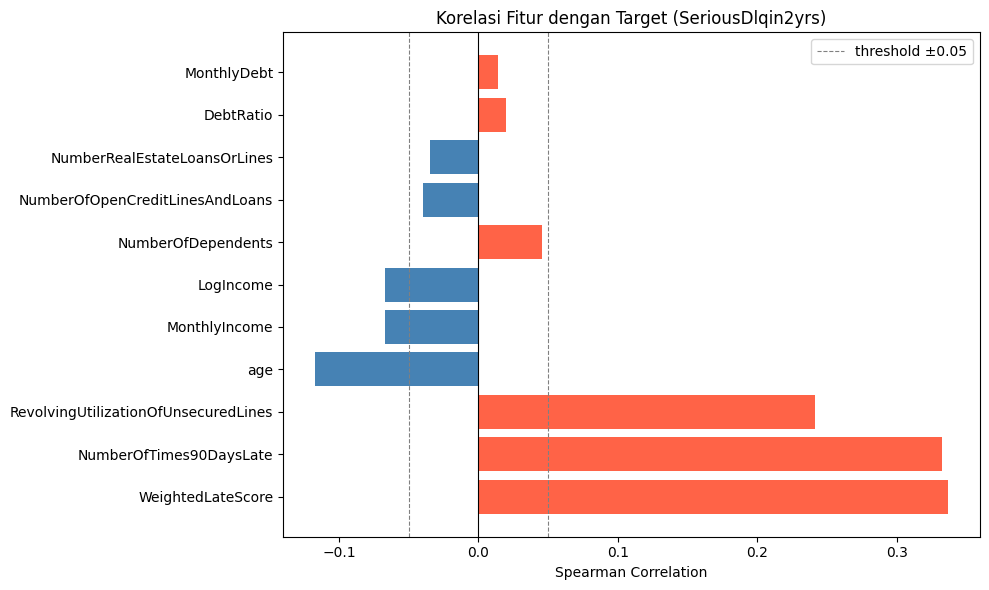

In [44]:
# Visualisasi korelasi
plt.figure(figsize=(10, 6))
colors = ['tomato' if x > 0 else 'steelblue' for x in corr_df['Spearman Correlation']]
bars = plt.barh(corr_df['Fitur'], corr_df['Spearman Correlation'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.axvline(x=0.05, color='gray', linewidth=0.8, linestyle='--', label='threshold ±0.05')
plt.axvline(x=-0.05, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Spearman Correlation')
plt.title('Korelasi Fitur dengan Target (SeriousDlqin2yrs)')
plt.legend()
plt.tight_layout()
plt.show()

Korelasi Positif dengan Default (semakin tinggi = semakin berisiko default):

- WeightedLateScore — 0.3369, korelasi tertinggi, konfirmasi fitur terpenting
- NumberOfTimes90DaysLate — 0.3326, hampir sama dengan WeightedLateScore (wajar karena WeightedLateScore dihitung dari sini)
- RevolvingUtilizationOfUnsecuredLines — 0.2410, konsisten dengan temuan distribusi per kelas tadi

Korelasi Negatif (semakin tinggi = semakin aman):

- age — -0.1173, orang lebih tua lebih aman, masuk akal secara bisnis
- MonthlyIncome & LogIncome — -0.0673, income lebih tinggi = lebih aman

Korelasi Sangat Lemah (di bawah threshold 0.05):

- DebtRatio — 0.0197
- MonthlyDebt — 0.0142

Ini menarik — DebtRatio dan MonthlyDebt korelasinya sangat lemah meskipun p-value signifikan. P-value signifikan tidak selalu berarti korelasinya kuat — dengan 149k data, bahkan korelasi sangat kecil pun bisa signifikan secara statistik.

Kesimpulan EDA:
- Kandidat fitur yang perlu dipertimbangkan untuk di-drop di feature selection: DebtRatio dan MonthlyDebt karena korelasi sangat lemah dengan target.

# V. Feature Engineering

In [45]:
# Train Test Split — stratified karena imbalanced
from sklearn.model_selection import train_test_split

# Definisikan fitur dan target
features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
    'NumberOfDependents', 'LogIncome', 'MonthlyDebt', 'WeightedLateScore',
    'NumberOfTimes90DaysLate'
]

target = 'SeriousDlqin2yrs'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # penting karena imbalanced
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"\nDistribusi y_train:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nDistribusi y_test:\n{y_test.value_counts(normalize=True).round(4)}")

X_train shape: (119512, 10)
X_test shape : (29878, 10)

Distribusi y_train:
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64

Distribusi y_test:
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64


In [46]:
# Handling Missing Value — imputasi dengan median dari train set
cols_impute = ['LogIncome', 'MonthlyDebt', 'NumberOfDependents']

# Hitung median dari train set saja
medians = X_train[cols_impute].median()
print("Median dari train set:")
print(medians)

# Terapkan ke train dan test
X_train = X_train.copy()
X_test = X_test.copy()

X_train[cols_impute] = X_train[cols_impute].fillna(medians)
X_test[cols_impute] = X_test[cols_impute].fillna(medians)

# Verifikasi
print(f"\nMissing values X_train setelah imputasi:")
print(X_train.isnull().sum())
print(f"\nMissing values X_test setelah imputasi:")
print(X_test.isnull().sum())

Median dari train set:
LogIncome             8.594339
MonthlyDebt           7.387459
NumberOfDependents    0.000000
dtype: float64

Missing values X_train setelah imputasi:
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
DebtRatio                               0
NumberOfOpenCreditLinesAndLoans         0
NumberRealEstateLoansOrLines            0
NumberOfDependents                      0
LogIncome                               0
MonthlyDebt                             0
WeightedLateScore                       0
NumberOfTimes90DaysLate                 0
dtype: int64

Missing values X_test setelah imputasi:
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
DebtRatio                               0
NumberOfOpenCreditLinesAndLoans         0
NumberRealEstateLoansOrLines            0
NumberOfDependents                      0
LogIncome                               0
MonthlyDebt                             0
WeightedLateScore

In [47]:
from feature_engine.outliers import Winsorizer

# Kolom yang perlu diwinsorisasi berdasarkan temuan EDA
cols_to_winsorize = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'LogIncome',
    'MonthlyDebt',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

# Fit hanya dari train set
winsorizer = Winsorizer(capping_method='iqr', tail='both', fold=1.5,
                        variables=cols_to_winsorize)
winsorizer.fit(X_train)

# Transform ke train dan test
X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

# Verifikasi — cek statistik sebelum dan sesudah
print("Statistik X_train setelah Winsorizing:")
print(X_train[cols_to_winsorize].describe().loc[['min', 'max']].round(3))

Statistik X_train setelah Winsorizing:
     RevolvingUtilizationOfUnsecuredLines  DebtRatio  LogIncome  MonthlyDebt  \
min                                 0.000      0.000      7.308        5.048   
max                                 1.345      1.911      9.870        9.497   

     NumberOfOpenCreditLinesAndLoans  NumberRealEstateLoansOrLines  \
min                              0.0                           0.0   
max                             20.0                           5.0   

     NumberOfDependents  
min                 0.0  
max                 2.5  


- RevolvingUtilizationOfUnsecuredLines — max dari 50708 → 1.345 ✅
- DebtRatio — max dari 329664 → 1.911 ✅
- NumberOfDependents — max dari 20 → 2.5 ✅
- NumberOfOpenCreditLinesAndLoans — max dari 58 → 20 ✅

In [48]:
# Feature selection dengan Spearman pada train set yang sudah bersih
from scipy.stats import spearmanr

correlations = []

for col in X_train.columns:
    corr, p_value = spearmanr(X_train[col], y_train)
    correlations.append({
        'Fitur': col,
        'Spearman Correlation': round(corr, 4),
        'P-Value': round(p_value, 6),
        'Signifikan (p<0.05)': '✓' if p_value < 0.05 else '✗'
    })

corr_df = pd.DataFrame(correlations).sort_values('Spearman Correlation', key=abs, ascending=False)
print(corr_df.to_string(index=False))

                               Fitur  Spearman Correlation  P-Value Signifikan (p<0.05)
                   WeightedLateScore                0.3360 0.000000                   ✓
             NumberOfTimes90DaysLate                0.3318 0.000000                   ✓
RevolvingUtilizationOfUnsecuredLines                0.2413 0.000000                   ✓
                                 age               -0.1175 0.000000                   ✓
                           LogIncome               -0.0597 0.000000                   ✓
                  NumberOfDependents                0.0476 0.000000                   ✓
     NumberOfOpenCreditLinesAndLoans               -0.0411 0.000000                   ✓
        NumberRealEstateLoansOrLines               -0.0355 0.000000                   ✓
                           DebtRatio                0.0178 0.000000                   ✓
                         MonthlyDebt                0.0104 0.000316                   ✓


In [49]:
# Drop kolom yang redundant
cols_to_drop = ['NumberOfTimes90DaysLate', 'MonthlyDebt']

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print("Fitur final yang digunakan:")
for col in X_train.columns:
    print(f"  - {col}")
print(f"\nShape X_train: {X_train.shape}")
print(f"Shape X_test : {X_test.shape}")

Fitur final yang digunakan:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - DebtRatio
  - NumberOfOpenCreditLinesAndLoans
  - NumberRealEstateLoansOrLines
  - NumberOfDependents
  - LogIncome
  - WeightedLateScore

Shape X_train: (119512, 8)
Shape X_test : (29878, 8)


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler

# Pisahkan kolom berdasarkan distribusi
numerical_cols_normal = ['age', 'LogIncome']
numerical_cols_skewed = [
    'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio',
    'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
    'NumberOfDependents', 'WeightedLateScore'
]

# Column Transformer
transformer = ColumnTransformer([
    ('standard', StandardScaler(), numerical_cols_normal),
    ('robust', RobustScaler(), numerical_cols_skewed)
])

# Fit dari train, transform ke keduanya
X_train_final = transformer.fit_transform(X_train)
X_test_final = transformer.transform(X_test)

print(f"Shape X_train_final: {X_train_final.shape}")
print(f"Shape X_test_final : {X_test_final.shape}")

Shape X_train_final: (119512, 8)
Shape X_test_final : (29878, 8)


# VI. Model Definition

In [51]:
# Import semua library yang dibutuhkan
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hitung scale_pos_weight untuk handle imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"Negative: {neg:,} | Positive: {pos:,} | scale_pos_weight: {scale:.2f}")

Negative: 111,505 | Positive: 8,007 | scale_pos_weight: 13.93


In [ ]:
# Logistic Regression
model_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # handle imbalance
    random_state=42
)

# Random Forest
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handle imbalance
    random_state=42,
    n_jobs=-1
)

# XGBoost
model_xgb = XGBClassifier(
    scale_pos_weight=scale,  # handle imbalance
    eval_metric='logloss',
    random_state=42
)

# LightGBM
model_lgbm = LGBMClassifier(
    class_weight='balanced',  # handle imbalance
    random_state=42,
    n_jobs=-1
)

print("Semua model sklearn berhasil didefinisikan!")

Semua model sklearn berhasil didefinisikan!


In [53]:
# ANN dengan Keras
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # binary classification
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

model_ann = build_ann(input_dim=X_train_final.shape[1])
model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 192 (768.00 B)

# VII. Model Training

## 7.1. Logistic Regression

In [54]:
# Training Logistic Regression
print("Training Logistic Regression...")
model_lr.fit(X_train_final, y_train)
print("Logistic Regression selesai! ✓")

Training Logistic Regression...
Logistic Regression selesai! ✓


## 7.2. Training Random Forest

In [55]:
# Training Random Forest
print("Training Random Forest...")
model_rf.fit(X_train_final, y_train)
print("Random Forest selesai! ✓")

Training Random Forest...
Random Forest selesai! ✓


## 7.3. Training XGBoost

In [56]:
print("Training XGBoost...")
model_xgb.fit(X_train_final, y_train)
print("XGBoost selesai! ✓")

Training XGBoost...
XGBoost selesai! ✓


## 7.4. Training LightGBM

In [57]:
model_lgbm.fit(X_train_final, y_train)
print("LightGBM selesai! ✓")

[LightGBM] [Info] Number of positive: 8007, number of negative: 111505
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 119512, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM selesai! ✓


## 7.5. Training ANN

In [58]:
# Training ANN
print("Training ANN...")

# Hitung class weight untuk ANN
class_weight = {0: 1, 1: scale}

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

history = model_ann.fit(
    X_train_final, y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1
)
print("ANN selesai! ✓")

Training ANN...
Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.6981 - loss: 1.2005 - val_AUC: 0.8475 - val_loss: 0.4873
Epoch 2/50
 44/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8447 - loss: 0.9282

c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8442 - loss: 0.9210 - val_AUC: 0.8532 - val_loss: 0.4739
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8489 - loss: 0.8923 - val_AUC: 0.8545 - val_loss: 0.4746
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8558 - loss: 0.8840 - val_AUC: 0.8552 - val_loss: 0.4713
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8544 - loss: 0.8900 - val_AUC: 0.8553 - val_loss: 0.4774
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8545 - loss: 0.8885 - val_AUC: 0.8555 - val_loss: 0.4639
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8560 - loss: 0.8853 - val_AUC: 0.8555 - val_loss: 0.4708
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8590 - loss: 0.8835 - val_AUC: 0.8557 - val_loss: 0.4715
Epoch 9/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8584 - loss: 0.8742 - val_AUC: 0.8560 - val_loss: 0.4788
Epoch 10/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8578 

# VIII. Model Evaluation 1

In [59]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, is_ann=False):
    # Prediksi
    if is_ann:
        y_prob_train = model.predict(X_tr).flatten()
        y_prob_test = model.predict(X_te).flatten()
        y_pred_train = (y_prob_train >= 0.5).astype(int)
        y_pred_test = (y_prob_test >= 0.5).astype(int)
    else:
        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_te)
        y_prob_train = model.predict_proba(X_tr)[:, 1]
        y_prob_test = model.predict_proba(X_te)[:, 1]

    # AUC
    auc_train = roc_auc_score(y_tr, y_prob_train)
    auc_test = roc_auc_score(y_te, y_prob_test)

    print(f"\n{'='*55}")
    print(f"  MODEL: {name}")
    print(f"{'='*55}")
    print(f"\nAUC-ROC  — Train: {auc_train:.4f} | Test: {auc_test:.4f}")
    print(f"\n[Classification Report - TEST SET]")
    print(classification_report(y_te, y_pred_test, target_names=['Tidak Default', 'Default']))

    # Confusion matrix + ROC Curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred_test)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Default', 'Default'])
    disp.plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{name} — Confusion Matrix')

    # ROC Curve
    RocCurveDisplay.from_predictions(y_te, y_prob_test, ax=axes[1], name=name)
    axes[1].plot([0,1], [0,1], 'k--')
    axes[1].set_title(f'{name} — ROC Curve (AUC={auc_test:.4f})')

    plt.tight_layout()
    plt.show()

    return {
        'Model': name,
        'AUC Train': round(auc_train, 4),
        'AUC Test': round(auc_test, 4),
        'Recall Default (Test)': round(classification_report(y_te, y_pred_test, output_dict=True)['1']['recall'], 4),
        'F1 Default (Test)': round(classification_report(y_te, y_pred_test, output_dict=True)['1']['f1-score'], 4),
        'F1 Macro (Test)': round(classification_report(y_te, y_pred_test, output_dict=True)['macro avg']['f1-score'], 4),
    }


  MODEL: Logistic Regression

AUC-ROC  — Train: 0.8513 | Test: 0.8565

[Classification Report - TEST SET]
               precision    recall  f1-score   support

Tidak Default       0.98      0.80      0.88     27876
      Default       0.21      0.75      0.33      2002

     accuracy                           0.80     29878
    macro avg       0.60      0.78      0.61     29878
 weighted avg       0.93      0.80      0.84     29878



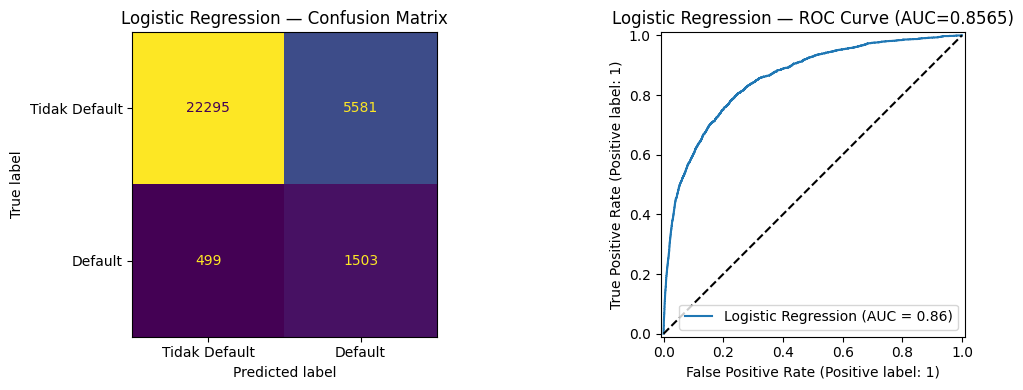


  MODEL: Random Forest

AUC-ROC  — Train: 0.9996 | Test: 0.8353

[Classification Report - TEST SET]
               precision    recall  f1-score   support

Tidak Default       0.94      0.99      0.97     27876
      Default       0.52      0.15      0.24      2002

     accuracy                           0.93     29878
    macro avg       0.73      0.57      0.60     29878
 weighted avg       0.91      0.93      0.92     29878



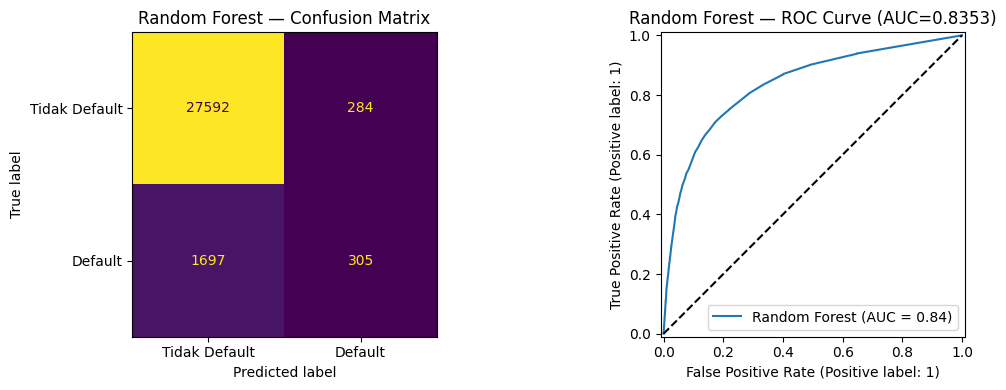


  MODEL: XGBoost

AUC-ROC  — Train: 0.9344 | Test: 0.8466

[Classification Report - TEST SET]
               precision    recall  f1-score   support

Tidak Default       0.98      0.83      0.90     27876
      Default       0.23      0.71      0.35      2002

     accuracy                           0.82     29878
    macro avg       0.60      0.77      0.62     29878
 weighted avg       0.93      0.82      0.86     29878



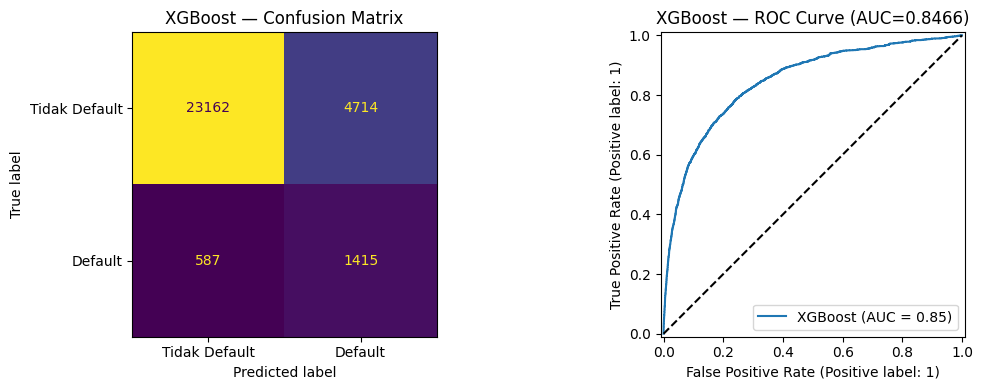

c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  MODEL: LightGBM

AUC-ROC  — Train: 0.8944 | Test: 0.8645

[Classification Report - TEST SET]
               precision    recall  f1-score   support

Tidak Default       0.98      0.80      0.88     27876
      Default       0.22      0.77      0.34      2002

     accuracy                           0.80     29878
    macro avg       0.60      0.79      0.61     29878
 weighted avg       0.93      0.80      0.85     29878



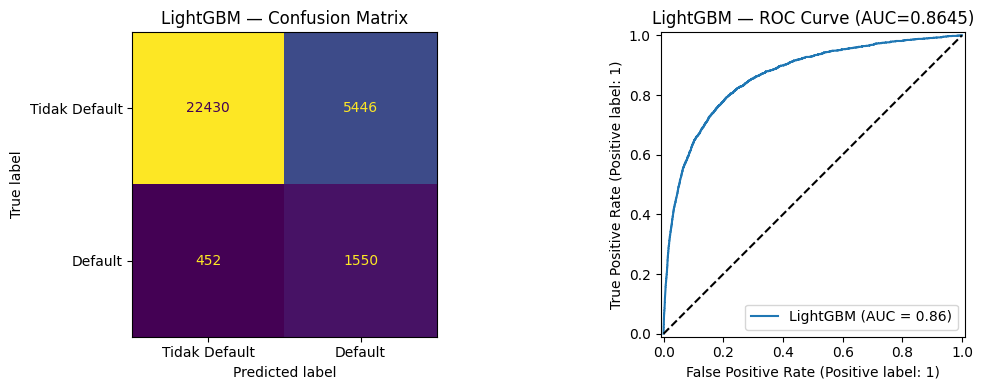

3735/3735 ━━━━━━━━━━━━━━━━━━━━ 2s 625us/step
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step

  MODEL: ANN

AUC-ROC  — Train: 0.8679 | Test: 0.8652

[Classification Report - TEST SET]
               precision    recall  f1-score   support

Tidak Default       0.98      0.77      0.86     27876
      Default       0.20      0.81      0.32      2002

     accuracy                           0.77     29878
    macro avg       0.59      0.79      0.59     29878
 weighted avg       0.93      0.77      0.82     29878



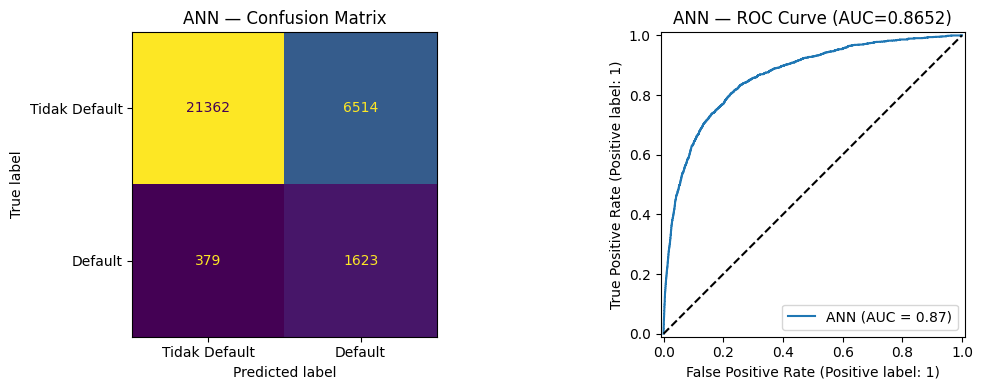

In [60]:
# Evaluasi semua model
results = []

results.append(evaluate_model('Logistic Regression', model_lr, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('Random Forest', model_rf, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('XGBoost', model_xgb, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('LightGBM', model_lgbm, X_train_final, X_test_final, y_train, y_test))
results.append(evaluate_model('ANN', model_ann, X_train_final, X_test_final, y_train, y_test, is_ann=True))

In [61]:
# Tabel perbandingan semua model
results_df = pd.DataFrame(results).sort_values('AUC Test', ascending=False)
print("\n=== RANGKUMAN PERBANDINGAN MODEL ===")
print(results_df.to_string(index=False))


=== RANGKUMAN PERBANDINGAN MODEL ===
              Model  AUC Train  AUC Test  Recall Default (Test)  F1 Default (Test)  F1 Macro (Test)
                ANN     0.8679    0.8652                 0.8107             0.3201           0.5906
           LightGBM     0.8944    0.8645                 0.7742             0.3445           0.6142
Logistic Regression     0.8513    0.8565                 0.7507             0.3308           0.6054
            XGBoost     0.9344    0.8466                 0.7068             0.3481           0.6227
      Random Forest     0.9996    0.8353                 0.1523             0.2354           0.6004


- Random Forest — Overfitting Parah
AUC Train 0.9996 vs Test 0.8353 — gap sangat besar. Recall Default hanya 15%! Model ini hampir tidak berguna untuk mendeteksi orang yang akan default.
- XGBoost — AUC cukup baik tapi Recall Default rendah
Recall Default 70% dengan AUC 0.8466 — masih bisa ditingkatkan.
- ANN & LightGBM — Paling Seimbang

- ANN: AUC tertinggi (0.8652), Recall Default tertinggi (81%) — tapi Train vs Test sangat dekat, tidak overfit
- LightGBM: AUC 0.8645, Recall Default 77%, F1 Default tertinggi (0.3445)

- Logistic Regression — Mengejutkan sebagai baseline
AUC 0.8565, Recall Default 75% — sangat kompetitif padahal model paling simple!
- Kesimpulan:
ANN dan LightGBM adalah kandidat terkuat untuk dilanjutkan ke hyperparameter tuning.

# IX. Model Training 2 - Hyperparameter Tuning

In [62]:
# Hyperparameter Tuning LightGBM dengan RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist_lgbm = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(20, 100),
    'min_child_samples': randint(10, 100),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

lgbm_base = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist_lgbm,
    n_iter=50,              # coba 50 kombinasi random
    scoring='roc_auc',      # optimasi berdasarkan AUC
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lgbm.fit(X_train_final, y_train)

print(f"\nBest Parameters: {random_search_lgbm.best_params_}")
print(f"Best AUC CV Score: {random_search_lgbm.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 8007, number of negative: 111505
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004987 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 119512, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [63]:
# LightGBM dengan parameter terbaik
model_lgbm_tuned = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    **random_search_lgbm.best_params_
)

model_lgbm_tuned.fit(X_train_final, y_train)
print("LightGBM Tuned selesai! ✓")

[LightGBM] [Info] Number of positive: 8007, number of negative: 111505
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 119512, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [64]:
# Tuning ANN — coba beberapa konfigurasi
def build_ann_tuned(input_dim, units_1=128, units_2=64, units_3=32, 
                     dropout_rate=0.3, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(units_1, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(units_2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(units_3, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# Konfigurasi yang akan dicoba
configs = [
    {'units_1': 128, 'units_2': 64,  'units_3': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'units_1': 128, 'units_2': 64,  'units_3': 32, 'dropout_rate': 0.4, 'learning_rate': 0.0005},
]

ann_results = []

for i, cfg in enumerate(configs):
    print(f"\nMencoba konfigurasi {i+1}: {cfg}")
    m = build_ann_tuned(input_dim=X_train_final.shape[1], **cfg)
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5,
        restore_best_weights=True, mode='max'
    )
    
    m.fit(
        X_train_final, y_train,
        epochs=50,
        batch_size=512,
        validation_split=0.2,
        class_weight=class_weight,
        callbacks=[early_stopping],
        verbose=0  # silent agar tidak banjir output
    )
    
    y_prob = m.predict(X_test_final).flatten()
    auc = roc_auc_score(y_test, y_prob)
    print(f"AUC Test: {auc:.4f}")
    ann_results.append({'config': i+1, 'auc': auc, 'model': m, 'params': cfg})

# Pilih konfigurasi terbaik
best_ann = max(ann_results, key=lambda x: x['auc'])
model_ann_tuned = best_ann['model']
print(f"\nKonfigurasi terbaik: {best_ann['config']} dengan AUC: {best_ann['auc']:.4f}")
print(f"Params: {best_ann['params']}")


Mencoba konfigurasi 1: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001}


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 650us/step
AUC Test: 0.8649

Mencoba konfigurasi 2: {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001}


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 704us/step
AUC Test: 0.8631

Mencoba konfigurasi 3: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout_rate': 0.4, 'learning_rate': 0.0005}


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step
AUC Test: 0.8658

Konfigurasi terbaik: 3 dengan AUC: 0.8658
Params: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout_rate': 0.4, 'learning_rate': 0.0005}


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  MODEL: LightGBM Tuned

AUC-ROC  — Train: 0.8744 | Test: 0.8664

[Classification Report - TEST SET]
               precision    recall  f1-score   support

Tidak Default       0.98      0.79      0.88     27876
      Default       0.22      0.79      0.34      2002

     accuracy                           0.79     29878
    macro avg       0.60      0.79      0.61     29878
 weighted avg       0.93      0.79      0.84     29878



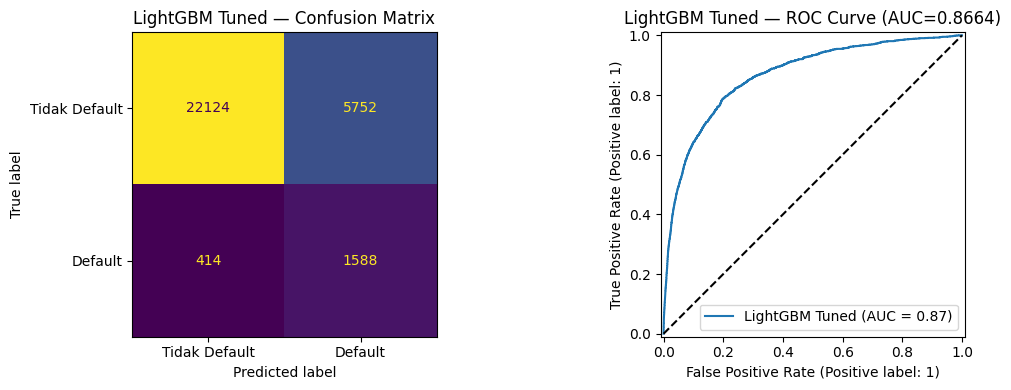

3735/3735 ━━━━━━━━━━━━━━━━━━━━ 2s 653us/step
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step

  MODEL: ANN Tuned

AUC-ROC  — Train: 0.8684 | Test: 0.8658

[Classification Report - TEST SET]
               precision    recall  f1-score   support

Tidak Default       0.98      0.78      0.87     27876
      Default       0.21      0.80      0.33      2002

     accuracy                           0.78     29878
    macro avg       0.59      0.79      0.60     29878
 weighted avg       0.93      0.78      0.83     29878



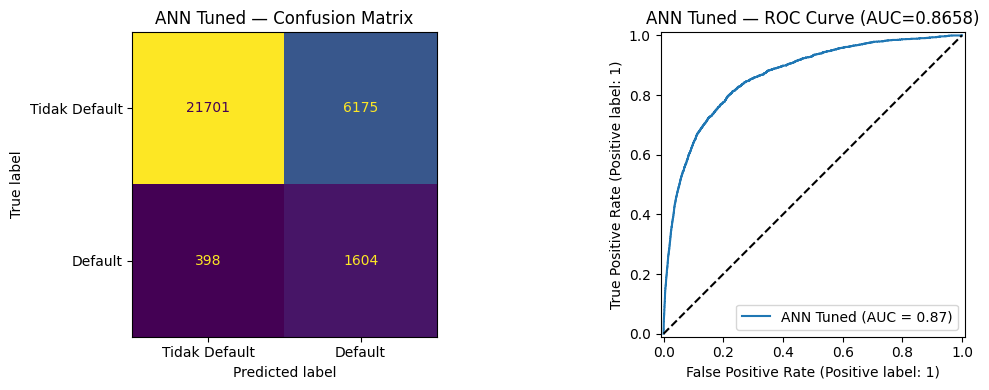

In [65]:
# Evaluasi model tuned
results_tuned = []

results_tuned.append(evaluate_model('LightGBM Tuned', model_lgbm_tuned, 
                                     X_train_final, X_test_final, y_train, y_test))
results_tuned.append(evaluate_model('ANN Tuned', model_ann_tuned, 
                                     X_train_final, X_test_final, y_train, y_test, is_ann=True))

In [66]:
# Perbandingan baseline vs tuned
print("=== BASELINE vs TUNED ===\n")

baseline = pd.DataFrame([
    {'Model': 'LightGBM Baseline', 'AUC Test': 0.8645, 'Recall Default': 0.7742, 'F1 Default': 0.3445},
    {'Model': 'ANN Baseline',      'AUC Test': 0.8652, 'Recall Default': 0.8107, 'F1 Default': 0.3201},
])

tuned = pd.DataFrame([{
    'Model': r['Model'],
    'AUC Test': r['AUC Test'],
    'Recall Default': r['Recall Default (Test)'],
    'F1 Default': r['F1 Default (Test)']
} for r in results_tuned])

comparison = pd.concat([baseline, tuned]).reset_index(drop=True)
print(comparison.to_string(index=False))

=== BASELINE vs TUNED ===

            Model  AUC Test  Recall Default  F1 Default
LightGBM Baseline    0.8645          0.7742      0.3445
     ANN Baseline    0.8652          0.8107      0.3201
   LightGBM Tuned    0.8664          0.7932      0.3400
        ANN Tuned    0.8658          0.8012      0.3280


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM Tuned — Sample Prediksi (n=20)

[Prediksi BENAR - sample 10]
 Aktual  Prediksi  Probabilitas Default (%)  Status
      1         1                     82.54 ✓ Benar
      0         0                     30.31 ✓ Benar
      0         0                     14.17 ✓ Benar
      0         0                     11.61 ✓ Benar
      0         0                     13.13 ✓ Benar
      0         0                      5.71 ✓ Benar
      0         0                      9.79 ✓ Benar
      0         0                      7.84 ✓ Benar
      0         0                      9.42 ✓ Benar
      0         0                     23.08 ✓ Benar

[Prediksi SALAH - sample 10]
 Aktual  Prediksi  Probabilitas Default (%)  Status
      0         1                     96.29 ✗ Salah
      1         0                     11.63 ✗ Salah
      0         1                     67.96 ✗ Salah
      0         1                     90.26 ✗ Salah
      0         1                     88.39 ✗ Salah
      0      

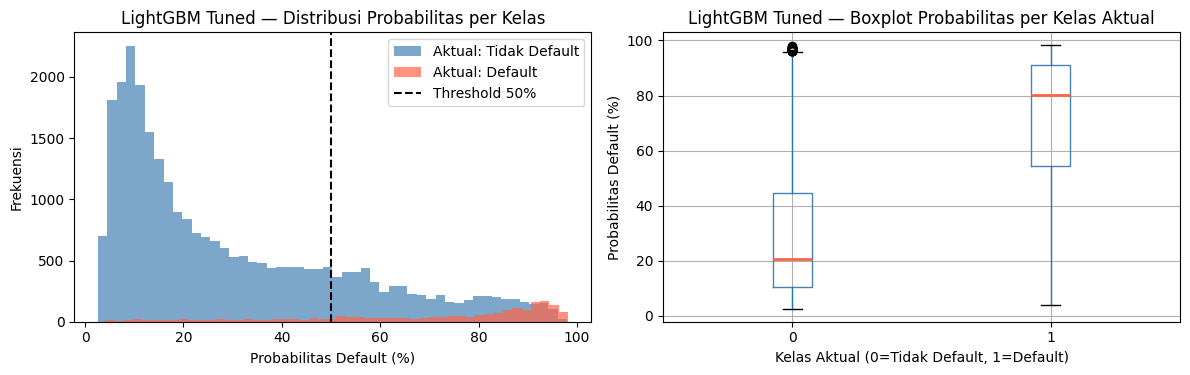

934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

  ANN Tuned — Sample Prediksi (n=20)

[Prediksi BENAR - sample 10]
 Aktual  Prediksi  Probabilitas Default (%)  Status
      1         1                 72.269997 ✓ Benar
      0         0                 26.540001 ✓ Benar
      0         0                 13.440000 ✓ Benar
      0         0                 15.660000 ✓ Benar
      0         0                  9.750000 ✓ Benar
      0         0                  7.420000 ✓ Benar
      0         0                 15.820000 ✓ Benar
      0         0                  8.250000 ✓ Benar
      0         0                 11.840000 ✓ Benar
      0         0                 20.959999 ✓ Benar

[Prediksi SALAH - sample 10]
 Aktual  Prediksi  Probabilitas Default (%)  Status
      0         1                 98.860001 ✗ Salah
      1         0                 14.280000 ✗ Salah
      0         1                 66.800003 ✗ Salah
      0         1                 86.540001 ✗ Salah
      0         1            

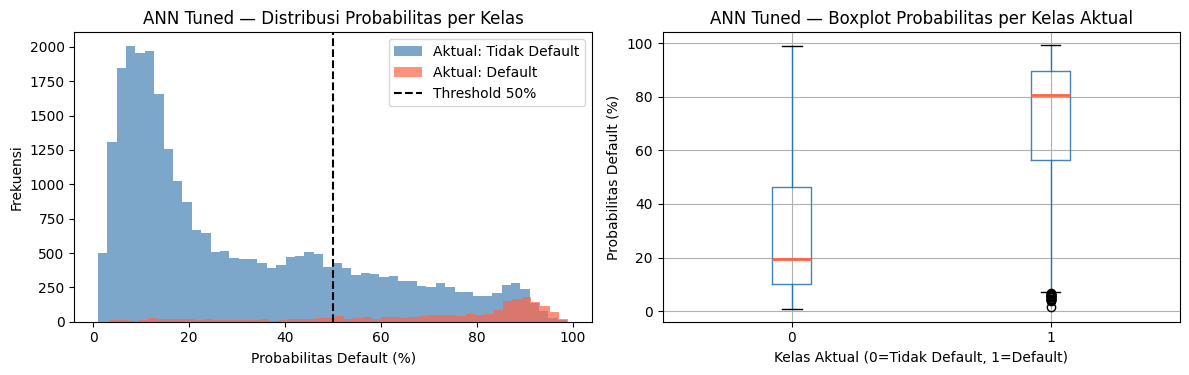

In [67]:
# Tampilkan prediksi dengan probabilitas
def show_predictions_with_proba(name, model, X_te, y_te, is_ann=False, n_samples=20):
    if is_ann:
        y_prob = model.predict(X_te).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_prob = model.predict_proba(X_te)[:, 1]
        y_pred = model.predict(X_te)
    
    pred_df = pd.DataFrame({
        'Aktual': y_te.values,
        'Prediksi': y_pred,
        'Probabilitas Default (%)': (y_prob * 100).round(2),
        'Status': np.where(y_pred == y_te.values, '✓ Benar', '✗ Salah')
    })
    
    print(f"\n{'='*60}")
    print(f"  {name} — Sample Prediksi (n={n_samples})")
    print(f"{'='*60}")
    
    # Tampilkan sample: benar dan salah
    print("\n[Prediksi BENAR - sample 10]")
    print(pred_df[pred_df['Status'] == '✓ Benar'].head(10).to_string(index=False))
    
    print("\n[Prediksi SALAH - sample 10]")
    print(pred_df[pred_df['Status'] == '✗ Salah'].head(10).to_string(index=False))
    
    # Distribusi probabilitas per kelas aktual
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(pred_df[pred_df['Aktual']==0]['Probabilitas Default (%)'], 
                 bins=50, color='steelblue', alpha=0.7, label='Aktual: Tidak Default')
    axes[0].hist(pred_df[pred_df['Aktual']==1]['Probabilitas Default (%)'], 
                 bins=50, color='tomato', alpha=0.7, label='Aktual: Default')
    axes[0].axvline(50, color='black', linestyle='--', label='Threshold 50%')
    axes[0].set_xlabel('Probabilitas Default (%)')
    axes[0].set_ylabel('Frekuensi')
    axes[0].set_title(f'{name} — Distribusi Probabilitas per Kelas')
    axes[0].legend()
    
    # Boxplot probabilitas per kelas
    pred_df.boxplot(column='Probabilitas Default (%)', by='Aktual', ax=axes[1],
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='tomato', linewidth=2))
    axes[1].set_title(f'{name} — Boxplot Probabilitas per Kelas Aktual')
    axes[1].set_xlabel('Kelas Aktual (0=Tidak Default, 1=Default)')
    axes[1].set_ylabel('Probabilitas Default (%)')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.show()
    
    return pred_df

# Jalankan untuk kedua model tuned
pred_lgbm = show_predictions_with_proba('LightGBM Tuned', model_lgbm_tuned, 
                                         X_test_final, y_test)
pred_ann = show_predictions_with_proba('ANN Tuned', model_ann_tuned, 
                                        X_test_final, y_test, is_ann=True)

LIGHTGBM TUNED


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


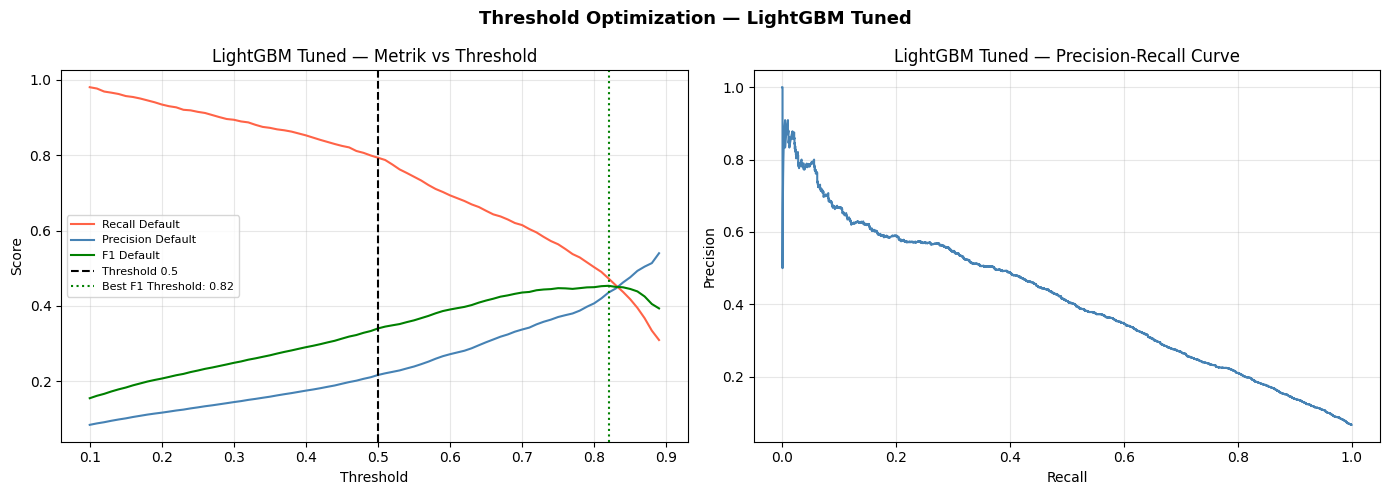


 Threshold  Recall Default  Precision Default   F1 Default
------------------------------------------------------------
       0.2          0.9346             0.1163       0.2069
       0.3          0.8941             0.1444       0.2486
       0.4          0.8526             0.1748       0.2902
       0.5          0.7932             0.2163       0.3400 ← default
       0.6          0.6933             0.2716       0.3903

Best F1 Threshold  : 0.82 → Recall: 0.4725 | Precision: 0.4353 | F1: 0.4532

ANN TUNED
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 646us/step


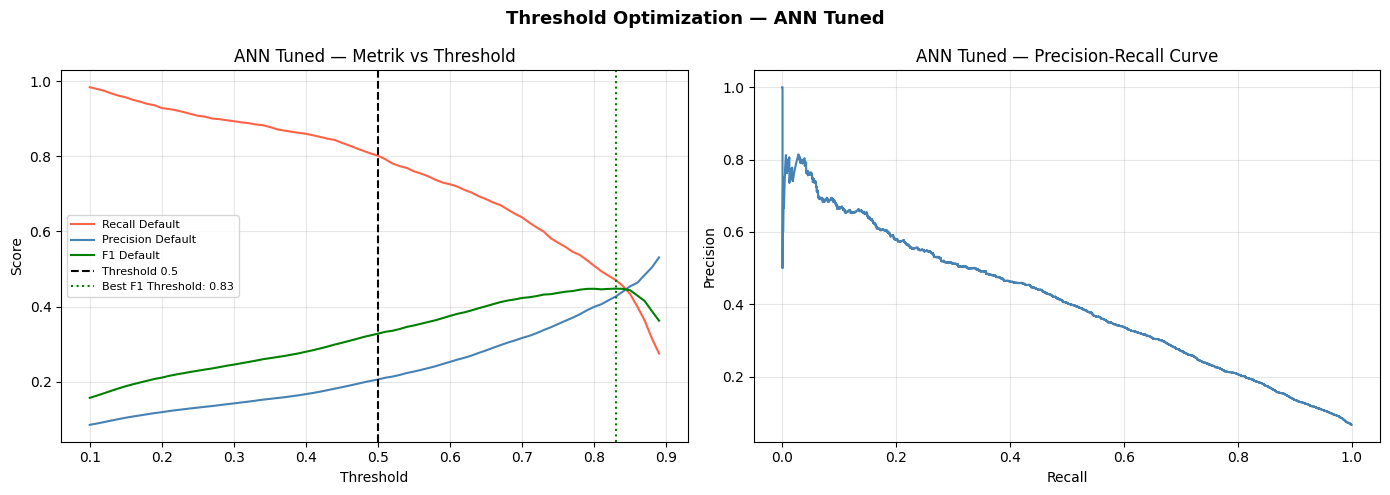


 Threshold  Recall Default  Precision Default   F1 Default
------------------------------------------------------------
       0.2          0.9281             0.1191       0.2111
       0.3          0.8931             0.1425       0.2457
       0.4          0.8596             0.1672       0.2800
       0.5          0.8012             0.2062       0.3280 ← default
       0.6          0.7253             0.2530       0.3752

Best F1 Threshold  : 0.83 → Recall: 0.4705 | Precision: 0.4270 | F1: 0.4477


In [68]:
# Threshold Optimization
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score

def plot_threshold_optimization(name, model, X_te, y_te, is_ann=False):
    if is_ann:
        y_prob = model.predict(X_te).flatten()
    else:
        y_prob = model.predict_proba(X_te)[:, 1]
    
    # Coba berbagai threshold
    thresholds = np.arange(0.1, 0.9, 0.01)
    recalls, precisions, f1s = [], [], []
    
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        recalls.append(recall_score(y_te, y_pred_t))
        precisions.append(precision_score(y_te, y_pred_t, zero_division=0))
        f1s.append(f1_score(y_te, y_pred_t))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Recall, Precision, F1 vs Threshold
    axes[0].plot(thresholds, recalls, color='tomato', label='Recall Default')
    axes[0].plot(thresholds, precisions, color='steelblue', label='Precision Default')
    axes[0].plot(thresholds, f1s, color='green', label='F1 Default')
    axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
    
    # Cari threshold optimal berdasarkan F1
    best_f1_idx = np.argmax(f1s)
    best_t_f1 = thresholds[best_f1_idx]
    axes[0].axvline(best_t_f1, color='green', linestyle=':', label=f'Best F1 Threshold: {best_t_f1:.2f}')
    
    # Cari threshold dengan Recall >= 0.80
    recall_80_idx = next((i for i, r in enumerate(recalls) if r >= 0.80), None)
    if recall_80_idx:
        best_t_recall = thresholds[recall_80_idx]
        axes[0].axvline(best_t_recall, color='tomato', linestyle=':', 
                        label=f'Recall≥80% Threshold: {best_t_recall:.2f}')
    
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title(f'{name} — Metrik vs Threshold')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    
    # Precision-Recall Curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_te, y_prob)
    axes[1].plot(rec_curve, prec_curve, color='steelblue')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{name} — Precision-Recall Curve')
    axes[1].grid(alpha=0.3)
    
    plt.suptitle(f'Threshold Optimization — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Tampilkan perbandingan threshold
    print(f"\n{'Threshold':>10} {'Recall Default':>15} {'Precision Default':>18} {'F1 Default':>12}")
    print("-" * 60)
    for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
        y_pred_t = (y_prob >= t).astype(int)
        r = recall_score(y_te, y_pred_t)
        p = precision_score(y_te, y_pred_t, zero_division=0)
        f = f1_score(y_te, y_pred_t)
        marker = ' ← default' if t == 0.5 else ''
        print(f"{t:>10.1f} {r:>15.4f} {p:>18.4f} {f:>12.4f}{marker}")
    
    print(f"\nBest F1 Threshold  : {best_t_f1:.2f} → Recall: {recalls[best_f1_idx]:.4f} | Precision: {precisions[best_f1_idx]:.4f} | F1: {f1s[best_f1_idx]:.4f}")
    if recall_80_idx:
        print(f"Recall≥80% Threshold: {best_t_recall:.2f} → Recall: {recalls[recall_80_idx]:.4f} | Precision: {precisions[recall_80_idx]:.4f} | F1: {f1s[recall_80_idx]:.4f}")
    
    return best_t_f1, best_t_recall if recall_80_idx else None

# Jalankan untuk kedua model
print("=" * 60)
print("LIGHTGBM TUNED")
best_t_f1_lgbm, best_t_recall_lgbm = plot_threshold_optimization(
    'LightGBM Tuned', model_lgbm_tuned, X_test_final, y_test)

print("\n" + "=" * 60)
print("ANN TUNED")
best_t_f1_ann, best_t_recall_ann = plot_threshold_optimization(
    'ANN Tuned', model_ann_tuned, X_test_final, y_test, is_ann=True)

Threshold 0.3 adalah pilihan paling masuk akal karena:

- Recall ~89% — 89% orang yang akan default berhasil terdeteksi 
- Precision 14% memang rendah, tapi di industri kredit lebih baik menolak 6 orang aman daripada meloloskan 1 orang yang akan default

In [69]:
# Model final: LightGBM Tuned dengan threshold 0.3
FINAL_THRESHOLD = 0.3

# Evaluasi final dengan threshold 0.3
y_prob_final = model_lgbm_tuned.predict_proba(X_test_final)[:, 1]
y_pred_final = (y_prob_final >= FINAL_THRESHOLD).astype(int)

print("=== EVALUASI FINAL — LightGBM Tuned (threshold=0.3) ===\n")
print(classification_report(y_test, y_pred_final, target_names=['Tidak Default', 'Default']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_final):.4f}")

=== EVALUASI FINAL — LightGBM Tuned (threshold=0.3) ===

               precision    recall  f1-score   support

Tidak Default       0.99      0.62      0.76     27876
      Default       0.14      0.89      0.25      2002

     accuracy                           0.64     29878
    macro avg       0.57      0.76      0.51     29878
 weighted avg       0.93      0.64      0.73     29878

AUC-ROC: 0.8664


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [70]:
# SHAP
import shap

# Buat explainer khusus untuk tree-based model
explainer = shap.TreeExplainer(model_lgbm_tuned)

# Hitung SHAP values — gunakan sample karena 119k baris terlalu besar
# Sample 2000 baris dari test set agar lebih cepat
sample_idx = np.random.seed(42)
X_test_sample = pd.DataFrame(X_test_final, columns=X_train.columns).sample(2000, random_state=42)

shap_values = explainer.shap_values(X_test_sample)

print(f"Shape SHAP values: {np.array(shap_values).shape}")
print("SHAP values berhasil dihitung!")

Shape SHAP values: (2000, 8)
SHAP values berhasil dihitung!


c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [71]:
# Fix untuk LightGBM binary classifier SHAP values
# shap_values adalah list [kelas_0, kelas_1] — kita ambil kelas 1 (Default)
shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"Shape SHAP values kelas Default: {shap_values_class1.shape}")
print(f"Kolom fitur: {X_test_sample.columns.tolist()}")

Shape SHAP values kelas Default: (2000, 8)
Kolom fitur: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'LogIncome', 'WeightedLateScore']


C:\Users\rezha\AppData\Local\Temp\ipykernel_19724\2646504419.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class1, X_test_sample, show=False)


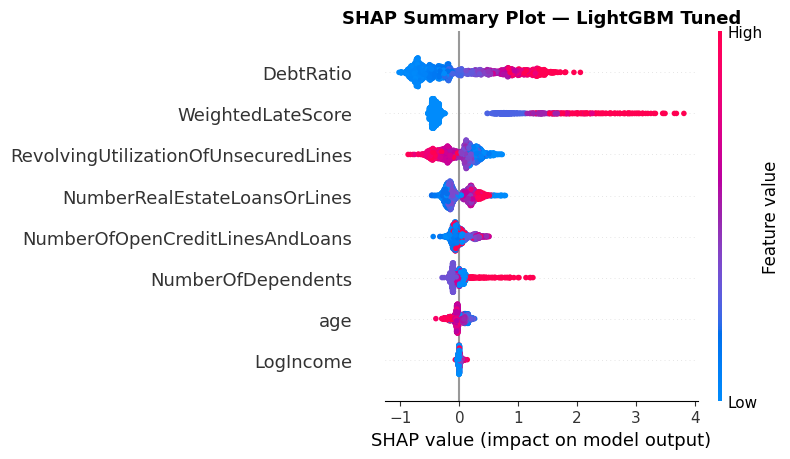

In [72]:
# 1. SHAP Summary Plot (Beeswarm) — fitur mana yang paling berpengaruh
plt.figure()
shap.summary_plot(shap_values_class1, X_test_sample, show=False)
plt.title('SHAP Summary Plot — LightGBM Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\rezha\AppData\Local\Temp\ipykernel_19724\2017170389.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class1, X_test_sample, plot_type='bar', show=False)


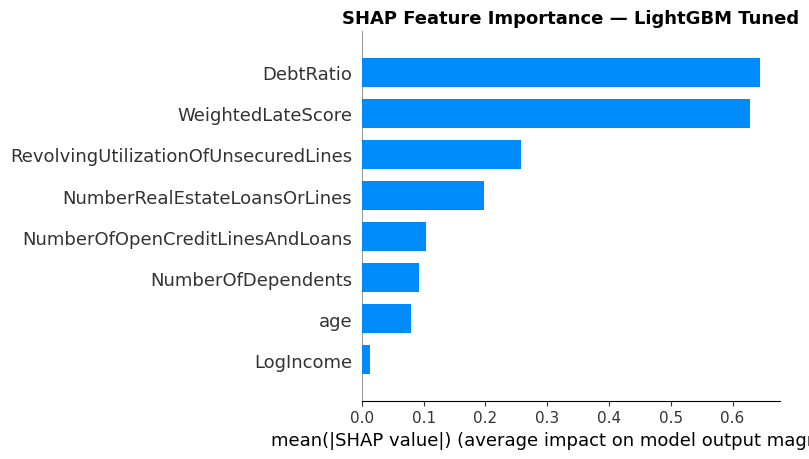

In [73]:
# 2. SHAP Bar Plot — rata-rata kontribusi absolut per fitur
plt.figure()
shap.summary_plot(shap_values_class1, X_test_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — LightGBM Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

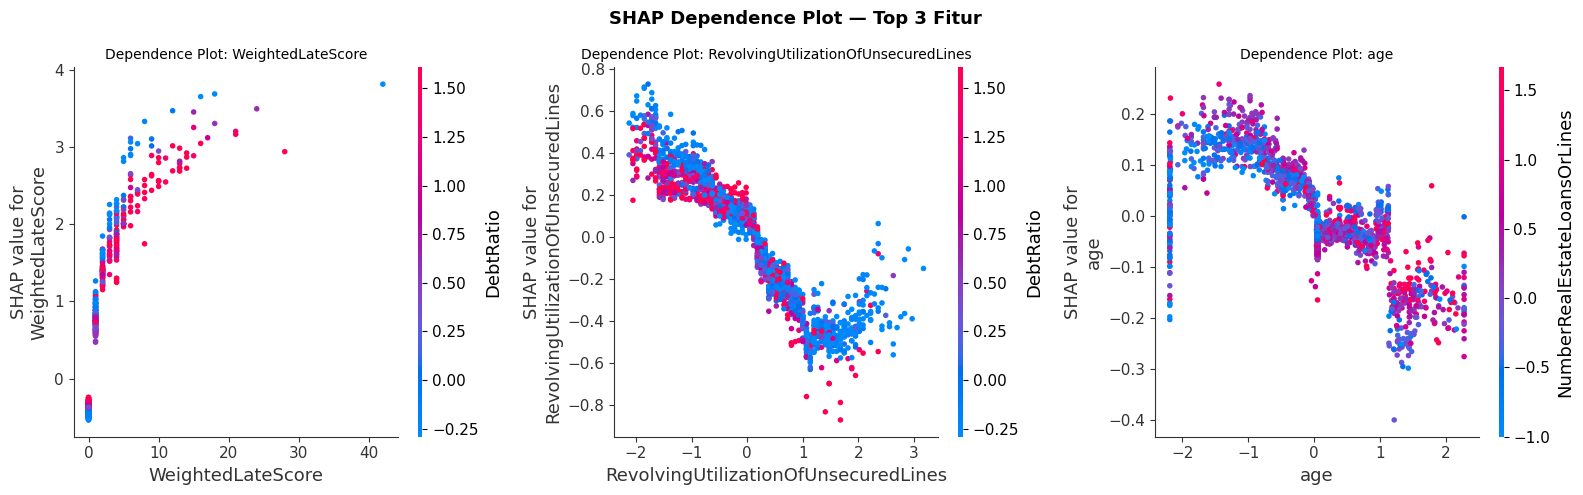

In [74]:
# 3. SHAP Dependence Plot — hubungan nilai fitur dengan SHAP value
# untuk 3 fitur terpenting
top_features = ['WeightedLateScore', 'RevolvingUtilizationOfUnsecuredLines', 'age']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values_class1, X_test_sample,
                         ax=axes[i], show=False)
    axes[i].set_title(f'Dependence Plot: {feat}', fontsize=10)

plt.suptitle('SHAP Dependence Plot — Top 3 Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

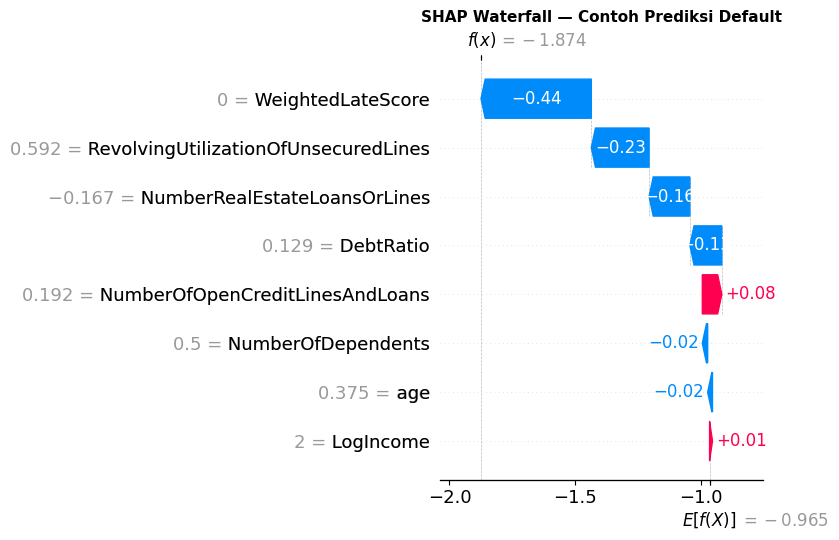

In [ ]:
# 4. SHAP Waterfall Plot — penjelasan prediksi untuk 1 individu
# Pilih 1 orang yang diprediksi Default dengan probabilitas tinggi
high_prob_idx = np.argmax(y_prob_final[y_test.index.isin(X_test_sample.index)])

explanation = shap.Explanation(
    values=shap_values_class1[high_prob_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_test_sample.iloc[high_prob_idx].values,
    feature_names=X_test_sample.columns.tolist()
)

plt.figure()
shap.waterfall_plot(explanation, show=False)
plt.title('SHAP Waterfall — Contoh Prediksi Default', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Probabilitas Default tertinggi: 97.71%
Data individu:
RevolvingUtilizationOfUnsecuredLines    -0.290118
age                                      0.051730
DebtRatio                                1.719285
NumberOfOpenCreditLinesAndLoans          2.225136
NumberRealEstateLoansOrLines             0.500000
NumberOfDependents                       0.500000
LogIncome                                0.000000
WeightedLateScore                       16.000000
Name: 1131, dtype: float64


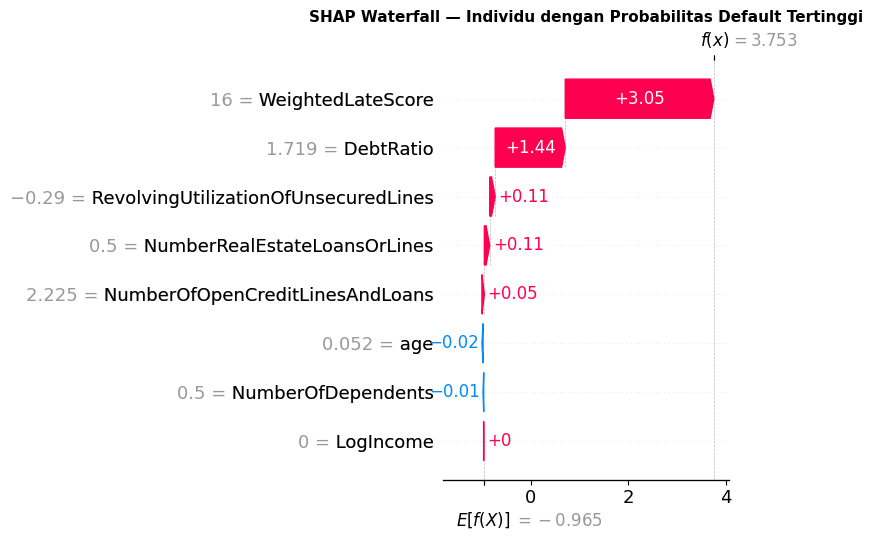

In [76]:
# Fix Waterfall Plot — pilih individu dengan probabilitas default tertinggi dari sample
X_test_sample_reset = X_test_sample.reset_index(drop=True)
y_prob_sample = model_lgbm_tuned.predict_proba(X_test_sample)[:, 1]

# Pilih index dengan probabilitas tertinggi
high_prob_idx = np.argmax(y_prob_sample)
print(f"Probabilitas Default tertinggi: {y_prob_sample[high_prob_idx]*100:.2f}%")
print(f"Data individu:\n{X_test_sample_reset.iloc[high_prob_idx]}")

explanation = shap.Explanation(
    values=shap_values_class1[high_prob_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_test_sample_reset.iloc[high_prob_idx].values,
    feature_names=X_test_sample.columns.tolist()
)

plt.figure()
shap.waterfall_plot(explanation, show=False)
plt.title('SHAP Waterfall — Individu dengan Probabilitas Default Tertinggi', 
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

1. Summary Plot (Beeswarm):

DebtRatio dan WeightedLateScore adalah dua fitur paling berpengaruh
DebtRatio tinggi (merah) → mendorong ke kanan (meningkatkan risiko default)
WeightedLateScore tinggi (merah) → SHAP value bisa sangat tinggi (sampai 4!) — ini fitur yang paling "ekstrem" pengaruhnya
age tinggi (merah) → SHAP value negatif → orang tua lebih aman

2. Bar Plot (Feature Importance):

DebtRatio dan WeightedLateScore hampir sama pentingnya (~0.63)
LogIncome hampir tidak berpengaruh sama sekali — konfirmasi keputusan kita tadi yang hampir drop fitur ini

3. Dependence Plot:

WeightedLateScore — hubungan monoton positif, semakin tinggi score telat bayar semakin berisiko, masuk akal
RevolvingUtilizationOfUnsecuredLines — ada pola U terbalik yang menarik, nilai tengah justru paling berisiko
age — jelas negatif, makin tua makin aman, konsisten dengan EDA

4. Waterfall Plot:

Individu ini f(x) = -1.874, di bawah base value -0.965 → model prediksi tidak default untuk orang ini
WeightedLateScore = 0 justru menurunkan risiko (-0.44)

WeightedLateScore = 16 — pernah telat bayar berkali-kali
DebtRatio = 1.719 — utangnya melebihi pendapatannya
RevolvingUtilizationOfUnsecuredLines = -0.29 — setelah scaling, artinya utilisasi kartu kredit rendah
LogIncome = 0 — income sangat rendah atau nol

Cara membaca waterfall:

Base value (rata-rata semua prediksi) = -0.965
Final f(x) = 3.753 — jauh di atas base value, artinya model sangat yakin ini akan Default

Kontribusi per fitur:

WeightedLateScore = 16 → +3.05 — kontributor terbesar, riwayat telat bayar yang parah
DebtRatio = 1.719 → +1.44 — utang melebihi income, sangat berisiko
Fitur lain kontribusinya kecil
age dan NumberOfDependents sedikit menurunkan risiko (-0.02, -0.01)

Insight bisnis yang bisa disampaikan ke stakeholder:
Orang ini ditolak kreditnya terutama karena riwayat telat bayar yang parah dan debt ratio yang sangat tinggi — dua sinyal paling kuat yang digunakan model untuk menentukan seseorang berisiko default.

#### KS-Statistics

In [1]:
# Example using best LightGBM
y_pred_proba = best_lgbm.predict_proba(X_test_final)[:, 1]

NameError: name 'best_lgbm' is not defined

# XI. Model Saving

# XII. Model Inference

In [4]:
test_df = pd.read_csv("inference_result.csv")
test_df

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Prob. Default (%),Risk Category
0,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0,48.70,🟡 Medium Risk
1,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0,37.44,🟢 Low Risk
2,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0,19.10,🟢 Low Risk
3,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0,53.54,🔴 High Risk
4,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0,59.53,🔴 High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...
81343,0.218356,56,0,0.295803,1500.0,3,0,0,0,0.0,82.89,🔴 High Risk
81344,0.718874,35,1,0.308047,4125.0,8,0,0,1,2.0,3.73,🟢 Low Risk
81345,0.045230,67,0,0.012198,5000.0,4,0,0,0,0.0,30.57,🟢 Low Risk
81346,0.282653,24,0,0.068522,1400.0,5,0,0,0,0.0,89.04,🔴 High Risk
